In [ ]:
!pip install ultralytics roboflow

In [ ]:

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="4zeiICVLMI4WTifh2Tv4")
project = rf.workspace("raghad-alharbi").project("ppe-detection-n3wro")
version = project.version(2)
dataset = version.download("yolov8-obb")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PPE-Detection-2 in yolov8-obb:: 100%|██████████| 307/307 [00:00<00:00, 7939.69it/s]


In [ ]:
from ultralytics import YOLO

model2 = YOLO('yolov8s-obb.pt')
results2 = model2.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,
    imgsz=640,
    lr0=0.001,
    patience=20
)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PPE-Detection-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=

In [ ]:
model2.predict(source=f"{dataset.location}/test/images", save=True, conf=0.25)


image 1/18 /content/PPE-Detection-2/test/images/12_jpg.rf.167c0d843926eab6dafd7d1d5738d68c.jpg: 640x640 3 helmets, 9.8ms
image 2/18 /content/PPE-Detection-2/test/images/14_jpg.rf.541c0722d1396b444f132da0f0721ba5.jpg: 640x640 2 helmets, 2 safety_vests, 9.8ms
image 3/18 /content/PPE-Detection-2/test/images/16_jpg.rf.e18c9cff16433ef4d7d7983292fcced0.jpg: 640x640 1 safety_vest, 9.8ms
image 4/18 /content/PPE-Detection-2/test/images/1_jpg.rf.0abaa47e8341678fe16d471a6da00c03.jpg: 640x640 1 safety_vest, 9.7ms
image 5/18 /content/PPE-Detection-2/test/images/20_jpg.rf.d12e84e864408353c12dda63ca28937d.jpg: 640x640 2 helmets, 1 safety_shoes, 9.8ms
image 6/18 /content/PPE-Detection-2/test/images/21_jpg.rf.5e97fcd29b3767c2d380de8df14e03fa.jpg: 640x640 2 safety_vests, 9.8ms
image 7/18 /content/PPE-Detection-2/test/images/23_jpg.rf.7def4203a842cb85f97ca22348c43c2a.jpg: 640x640 2 helmets, 4 safety_shoess, 1 safety_vest, 9.7ms
image 8/18 /content/PPE-Detection-2/test/images/30_jpg.rf.665674fa85c2e8eb4b

[ultralytics.engine.results.Results object with attributes:
 
 boxes: None
 depth: None
 keypoints: None
 masks: None
 names: {0: 'helmet', 1: 'safety_shoes', 2: 'safety_vest'}
 obb: ultralytics.engine.results.OBB object
 orig_img: array([[[ 61,  75,  93],
         [ 62,  76,  94],
         [ 65,  79,  97],
         ...,
         [ 35,  43,  42],
         [ 34,  42,  41],
         [ 33,  41,  40]],
 
        [[ 60,  74,  92],
         [ 62,  76,  94],
         [ 65,  79,  97],
         ...,
         [ 35,  43,  42],
         [ 34,  42,  41],
         [ 33,  41,  40]],
 
        [[ 59,  73,  91],
         [ 61,  75,  93],
         [ 65,  79,  97],
         ...,
         [ 35,  43,  42],
         [ 34,  42,  41],
         [ 33,  41,  40]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [

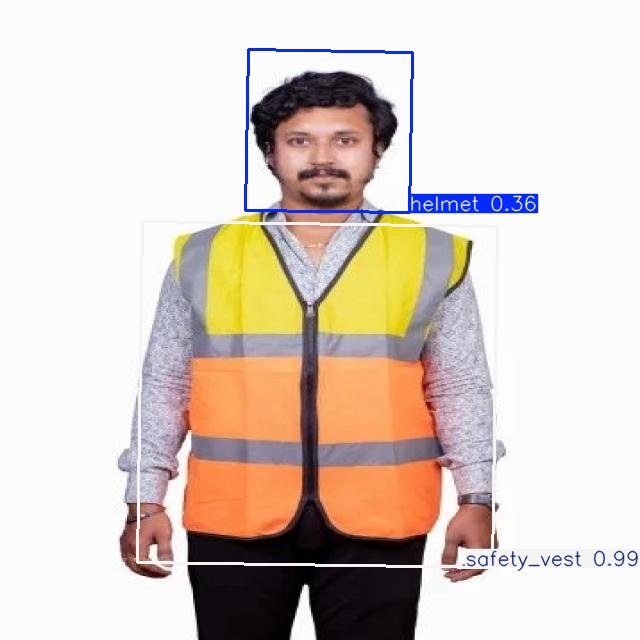

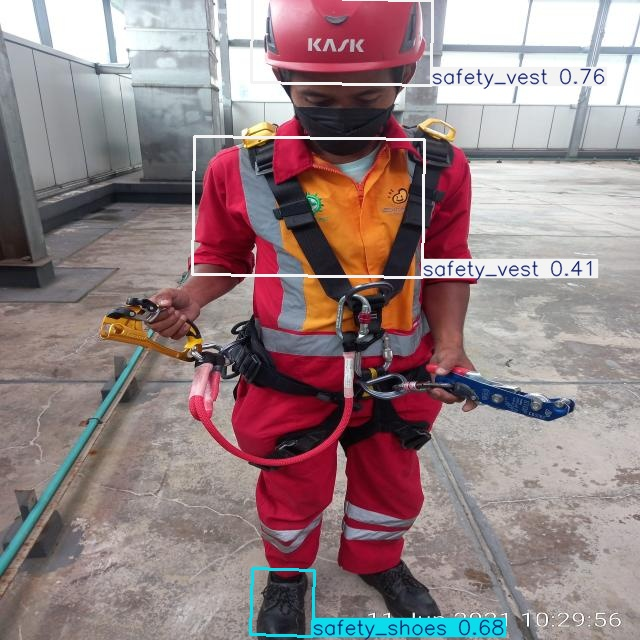

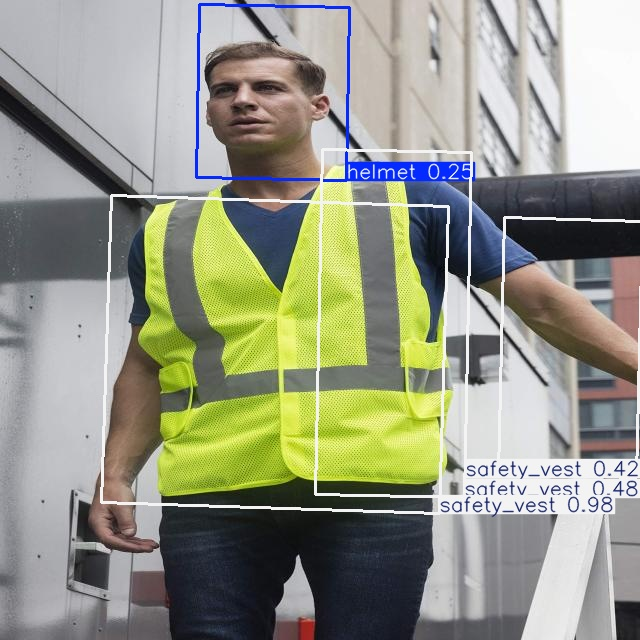

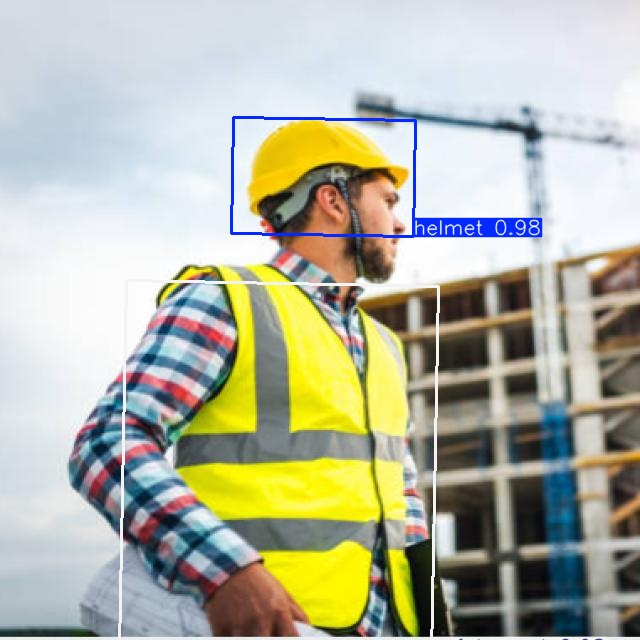

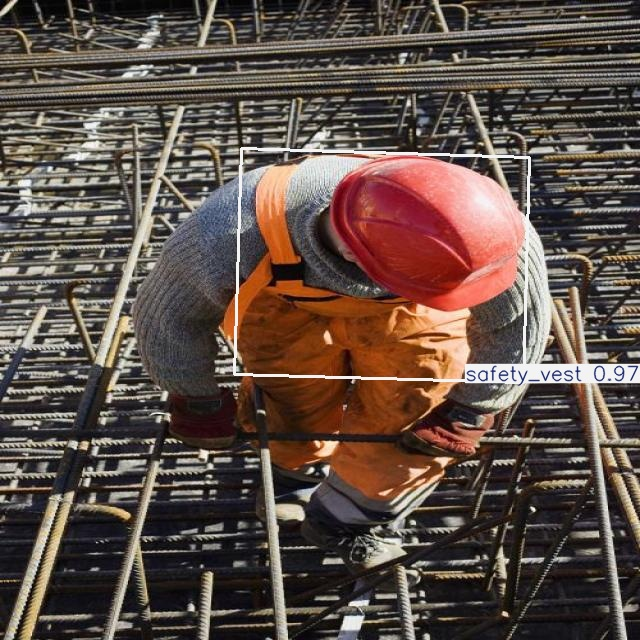

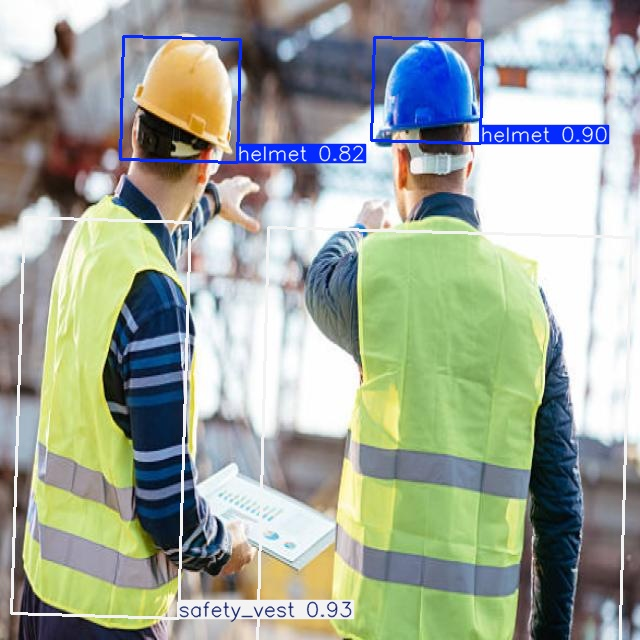

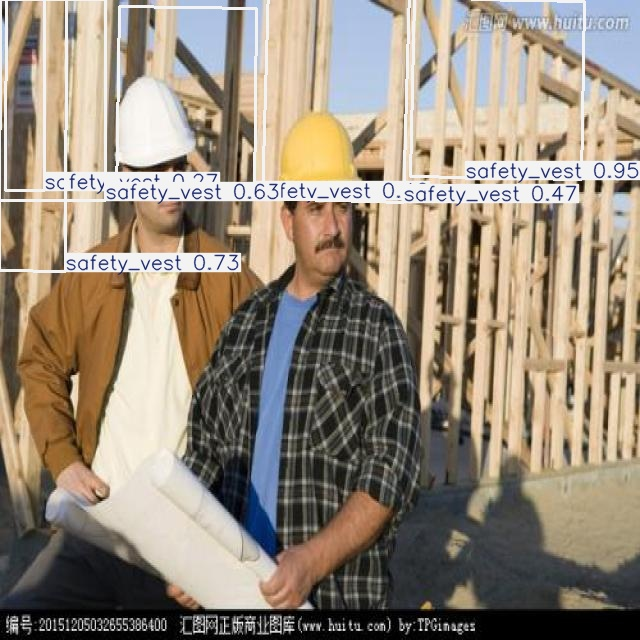

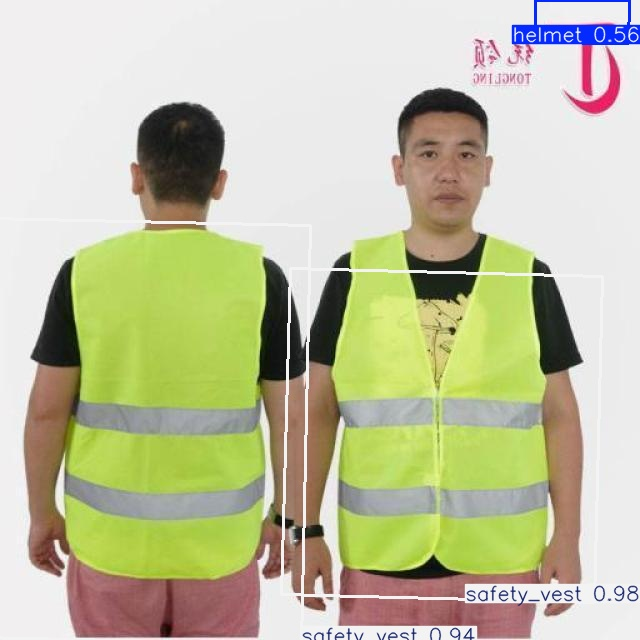

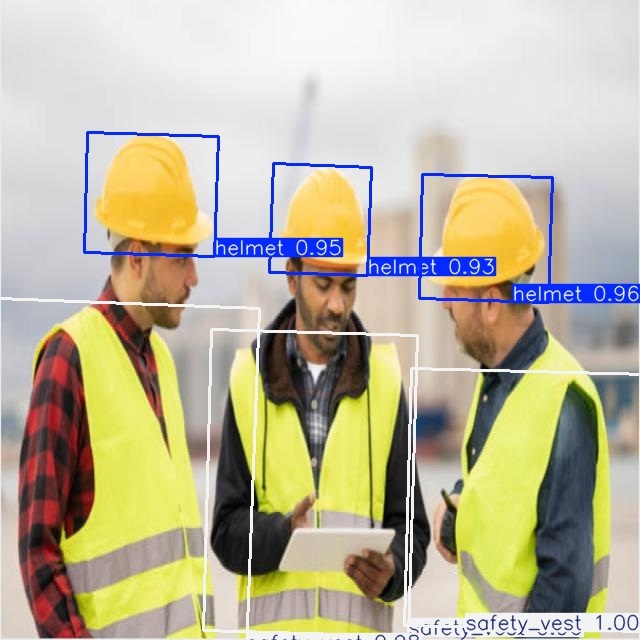

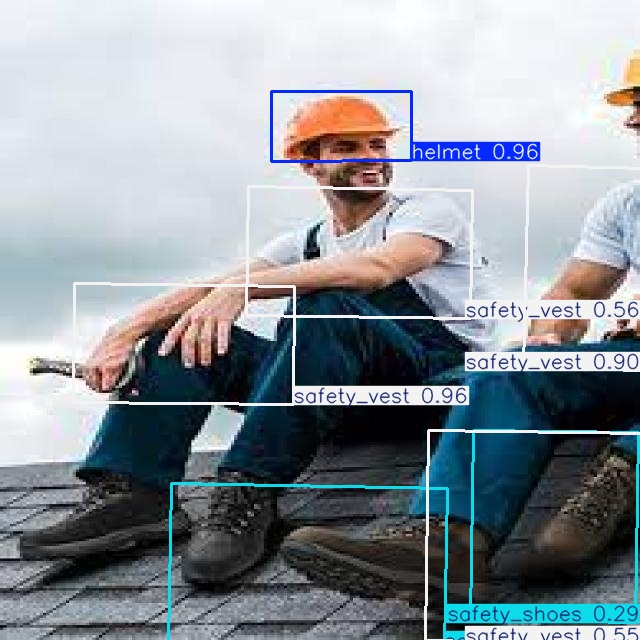

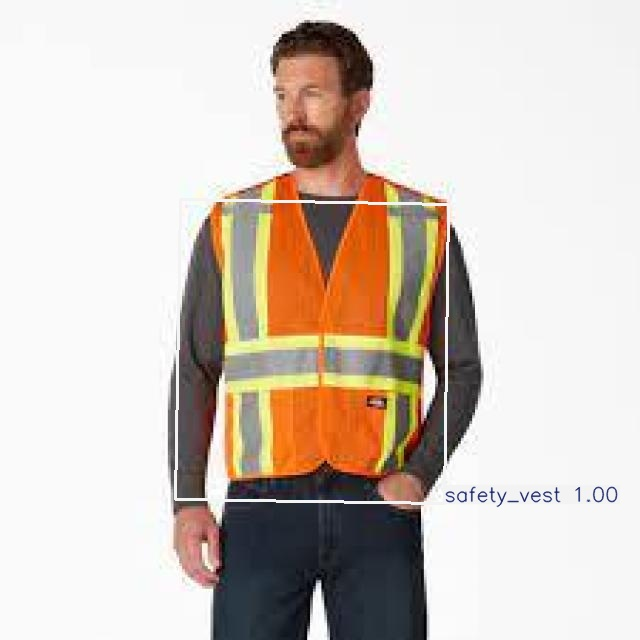

In [ ]:
import glob
from IPython.display import Image, display

for img_path in glob.glob('/content/runs/obb/predict/*.jpg'):
    display(Image(filename=img_path, width=500))

In [ ]:
metrics_test = model2.val(data=f"{dataset.location}/data.yaml", split='test')
print(metrics_test.results_dict)

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1389.3±266.5 MB/s, size: 46.4 KB)
val: Scanning /content/PPE-Detection-2/test/labels... 18 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 18/18 1.8Kit/s 0.0s
val: New cache created: /content/PPE-Detection-2/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9it/s 1.1s
                   all         18         51      0.746      0.695      0.696        0.5
                helmet         13         19      0.771      0.711      0.746      0.519
          safety_shoes          7         16      0.671        0.5      0.454      0.316
           safety_vest         11         16      0.794      0.875      0.887      0.666
Speed: 5.5ms preprocess, 24.9ms inference, 0.0ms loss, 4.7ms postprocess per image
Results saved to /content/runs/obb/val-3
{'metrics/precision(B)': 0.7455